# Phân cụm Ngày theo Hình thái Thời tiết & Ô nhiễm (K-Means)

**Mục tiêu**: Phân nhóm 366 ngày trong năm 2024 thành các cụm (clusters) có đặc điểm tương đồng về thời tiết và chất lượng không khí để tìm ra các quy luật theo mùa (Seasonal Patterns) và hình thái ô nhiễm đặc trưng.

**Phương pháp**:
- **Mô hình**: K-Means Clustering (Học máy không giám sát).
- **Kỹ thuật tối ưu**: Elbow Method (Tìm số cụm k tối ưu) & Silhouette Analysis.
- **Kỹ thuật trực quan hóa**: PCA (Principal Component Analysis) để giảm chiều dữ liệu từ nhiều biến xuống 2D.

**Chiến lược phân tích**: 
1. Chuẩn hóa dữ liệu (Scaling) để đồng bộ đơn vị đo.
2. Tìm số cụm hợp lý nhất (k).
3. Gán nhãn và định danh cho từng cụm (ví dụ: "Ngày Mưa Sạch", "Ngày Ô nhiễm Khô"...).

**Nguồn dữ liệu**: `processed/daily_weather_aqi_10.823_106.6296_2024.csv` - Dữ liệu tổng hợp theo ngày.

**Kết quả**:
- File CSV đã gán nhãn phân loại: `processed/daily_weather_aqi_clustered.csv`
- Biểu đồ phân cụm & Phân bố theo thời gian (Timeline).

## 1. Import Libraries và Load Data

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import calendar
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.dates as mdates
import os

# Cấu hình hiển thị
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [2]:
file_path = '../processed/daily_weather_aqi_10.823_106.6296_2024.csv'
df = pd.read_csv(file_path)

features = [
    'temp_mean',       # Nhiệt độ
    'precip_total',    # Lượng mưa
    'wind_speed_mean', # Tốc độ gió
    'uv_max',          # Bức xạ mặt trời
    'pm2_5_mean',      # Bụi mịn PM2.5
    'ozone_mean'       # Khí Ozone
]

# Loại bỏ dòng thiếu dữ liệu (nếu có) để thuật toán chạy ổn định
X = df[features].dropna()

print(f"✓ Data Loaded. Shape: {X.shape}")
print("✓ Features selected:", features)

✓ Data Loaded. Shape: (354, 6)
✓ Features selected: ['temp_mean', 'precip_total', 'wind_speed_mean', 'uv_max', 'pm2_5_mean', 'ozone_mean']


## 2. Chuẩn hóa Dữ liệu (Scaling)
Vì các biến có đơn vị khác nhau (ví dụ: Lượng mưa là mm, Bụi là µg/m³, Nhiệt độ là °C), nếu không chuẩn hóa, thuật toán sẽ bị sai lệch (biến nào có số lớn hơn sẽ chi phối kết quả). Ta dùng **StandardScaler** để đưa tất cả về cùng một tỷ lệ (mean=0, std=1).

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Chuyển lại thành DataFrame để dễ kiểm tra (Optional)
X_scaled_df = pd.DataFrame(X_scaled, columns=features, index=X.index)

print("✓ Data Scaled successfully.")
print("--- 5 dòng đầu sau khi chuẩn hóa ---")
display(X_scaled_df.head())

✓ Data Scaled successfully.
--- 5 dòng đầu sau khi chuẩn hóa ---


,temp_mean,precip_total,wind_speed_mean,uv_max,pm2_5_mean,ozone_mean
0,-0.61,-0.71,-1.43,-0.56,1.85,0.29
1,-0.36,-0.71,-1.40,-1.26,1.79,0.77
2,-0.36,-0.71,-1.16,-0.72,0.74,0.43
3,-0.61,-0.71,-1.25,-0.24,0.51,1.60
4,-0.93,-0.71,-1.76,-0.63,0.60,0.76


## 3. Xác định số cụm tối ưu (Elbow Method)
Để biết nên chia thành bao nhiêu nhóm (k=3, 4, hay 5?), ta chạy thuật toán K-Means với k từ 2 đến 10 để tìm "điểm khuỷu tay" (Elbow point) - nơi độ lỗi (Inertia) bắt đầu giảm chậm lại.

⏳ Đang chạy thử nghiệm tìm k tối ưu...


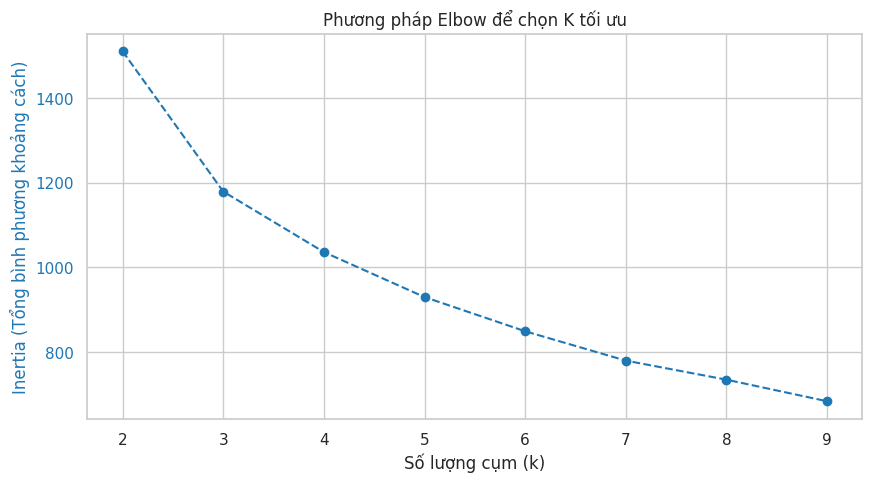

💡 GỢI Ý: Nhìn vào biểu đồ trên:
- Nếu đường gấp khúc rõ tại k=3 hoặc k=4, hãy chọn số đó.
- Với dữ liệu TP.HCM (Mưa/Khô) + Ô nhiễm, thường k=4 là hợp lý nhất.


In [4]:
inertia = []
silhouette_scores = []
K_range = range(2, 10)

print("⏳ Đang chạy thử nghiệm tìm k tối ưu...")

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    # Tính Silhouette Score để đánh giá độ tách biệt của các cụm
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)

# Vẽ biểu đồ Elbow và Silhouette
fig, ax1 = plt.subplots(figsize=(10, 5))

# Biểu đồ Inertia (Elbow)
color = 'tab:blue'
ax1.set_xlabel('Số lượng cụm (k)')
ax1.set_ylabel('Inertia (Tổng bình phương khoảng cách)', color=color)
ax1.plot(K_range, inertia, marker='o', color=color, linestyle='--')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_title('Phương pháp Elbow để chọn K tối ưu')
ax1.grid(True)

plt.show()

print("💡 GỢI Ý: Nhìn vào biểu đồ trên:")
print("- Nếu đường gấp khúc rõ tại k=3 hoặc k=4, hãy chọn số đó.")
print("- Với dữ liệu TP.HCM (Mưa/Khô) + Ô nhiễm, thường k=4 là hợp lý nhất.")

## 4. Huấn luyện Mô hình & Phân tích Cụm
Dựa vào kết quả trên, ta chọn **k=4** (đại diện cho 4 hình thái thời tiết chính: Mưa nhiều, Nắng nóng, Ô nhiễm khô, Giao mùa).

In [5]:
# === CẤU HÌNH SỐ CỤM ===
k_chosen = 4
# =======================

# 1. Chạy mô hình
kmeans = KMeans(n_clusters=k_chosen, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# 2. Gán kết quả vào DataFrame gốc
df_cluster = df.loc[X.index].copy()
df_cluster['Cluster'] = clusters

# 3. Tính thống kê trung bình để hiểu đặc điểm từng cụm
# (Cụm này nóng hay lạnh? Mưa hay nắng? Bụi nhiều hay ít?)
cluster_stats = df_cluster.groupby('Cluster')[features].mean()
cluster_stats['Số ngày'] = df_cluster['Cluster'].value_counts()

print(f"\n--- ĐẶC ĐIỂM TRUNG BÌNH CỦA {k_chosen} CỤM ---")
display(cluster_stats.round(2))

# 4. Tự động đặt tên cụm (Heuristic Naming)
# Logic: Nhìn vào số liệu trung bình để gán tên gợi nhớ
cluster_names = {}

for i, row in cluster_stats.iterrows():
    name_parts = []
    
    # Kiểm tra đặc điểm Mưa
    if row['precip_total'] > 5: 
        name_parts.append("Mưa")
    elif row['precip_total'] < 1: 
        name_parts.append("Khô")
        
    # Kiểm tra đặc điểm Nhiệt độ
    if row['temp_mean'] > 29.5: 
        name_parts.append("Nóng")
    elif row['temp_mean'] < 27.5: 
        name_parts.append("Mát")
        
    # Kiểm tra đặc điểm Ô nhiễm
    if row['pm2_5_mean'] > 30: 
        name_parts.append("Bụi cao")
    elif row['pm2_5_mean'] < 18: 
        name_parts.append("Sạch") # Thường do mưa rửa trôi
        
    # Nếu không có đặc điểm nào quá nổi bật
    if not name_parts:
        name_parts.append("Trung tính/Giao mùa")
        
    # Ghép tên lại
    cluster_names[i] = " - ".join(name_parts)

print("\n--- GỢI Ý TÊN CỤM (TỰ ĐỘNG) ---")
for k, v in cluster_names.items():
    print(f"Cụm {k}: {v}")

# Áp dụng tên vào DataFrame
df_cluster['Cluster_Name'] = df_cluster['Cluster'].map(cluster_names)
print("\n✓ Đã gán tên cụm thành công!")


--- ĐẶC ĐIỂM TRUNG BÌNH CỦA 4 CỤM ---


,temp_mean,precip_total,wind_speed_mean,uv_max,pm2_5_mean,ozone_mean,Số ngày
Cluster,,,,,,,
0,28.17,5.98,8.19,7.31,30.47,45.46,94
1,30.69,1.38,13.09,10.78,15.99,56.71,119
2,28.86,1.17,8.97,8.79,25.54,72.03,82
3,28.06,16.63,13.84,7.59,20.62,41.03,59



--- GỢI Ý TÊN CỤM (TỰ ĐỘNG) ---
Cụm 0: Mưa - Bụi cao
Cụm 1: Nóng - Sạch
Cụm 2: Trung tính/Giao mùa
Cụm 3: Mưa

✓ Đã gán tên cụm thành công!


## 5. Trực quan hóa Kết quả (Visualization)
Biến đổi dữ liệu từ 6 chiều (Nhiệt, Mưa, Gió, UV, Bụi, Ozone) xuống 2 chiều bằng **PCA** để vẽ lên mặt phẳng, giúp ta nhìn thấy sự phân tách giữa các nhóm ngày.

#### 5.1 PCA Plot

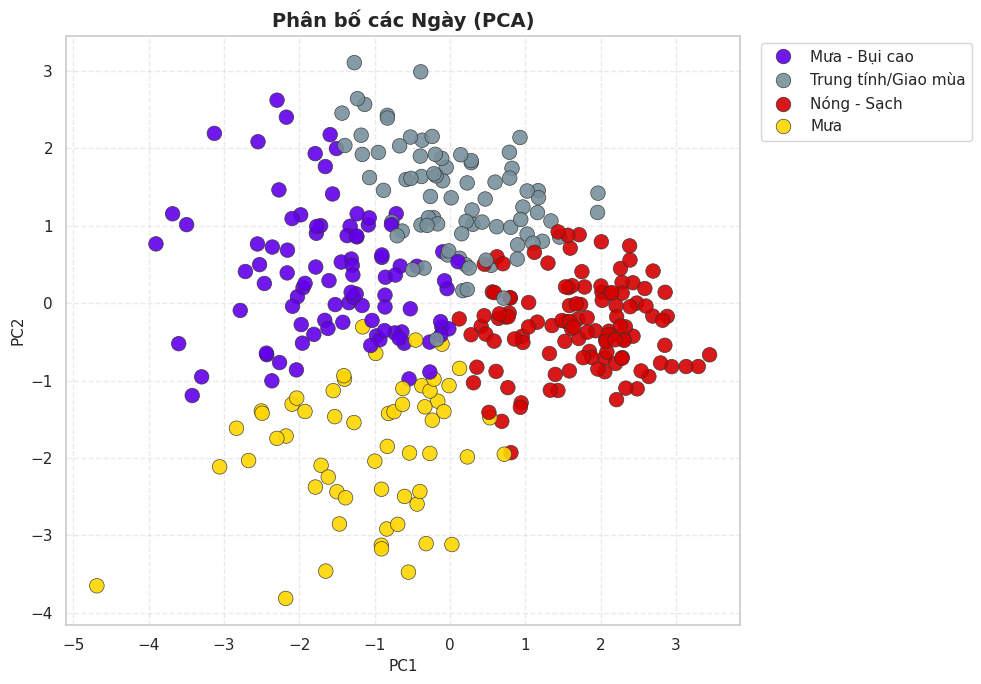

In [6]:
# 1. Prepare Data
features = ['temp_mean', 'precip_total', 'wind_speed_mean', 'uv_max', 'pm2_5_mean', 'ozone_mean']
X = df_cluster[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
df_pca['Cluster_Name'] = df_cluster['Cluster_Name'].values

# 2. Plot Setup (RAIN = YELLOW)
plt.figure(figsize=(10, 7))

palette_dict = {}
for name in df_pca['Cluster_Name'].unique():
    n = name.lower()
    # Logic màu theo yêu cầu:
    if 'bụi' in n or 'ô nhiễm' in n: palette_dict[name] = '#6200EA' # Tím đậm (Bụi)
    elif 'mưa' in n: palette_dict[name] = '#FFD600'                   # Vàng (Mưa)
    elif 'nóng' in n: palette_dict[name] = '#D50000'                  # Đỏ đậm (Nóng)
    elif 'khô' in n: palette_dict[name] = '#FF6D00'                   # Cam (Khô - để khác màu Vàng)
    elif 'sạch' in n or 'mát' in n: palette_dict[name] = '#00C853'    # Xanh lá (Sạch)
    else: palette_dict[name] = '#78909C'                              # Xám xanh

sns.scatterplot(
    data=df_pca, x='PC1', y='PC2', 
    hue='Cluster_Name', 
    palette=palette_dict,
    s=110, alpha=0.9, edgecolor='#333333', linewidth=0.5 # Thêm viền đen mảnh để màu Vàng dễ nhìn hơn
)

plt.title('Phân bố các Ngày (PCA)', fontsize=14, fontweight='bold')
plt.xlabel('PC1', fontsize=11)
plt.ylabel('PC2', fontsize=11)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../figures/10_kmeans_pca_scatter_yellow_rain.pdf', bbox_inches='tight')
plt.show()

#### 5.2 Timeline Plot

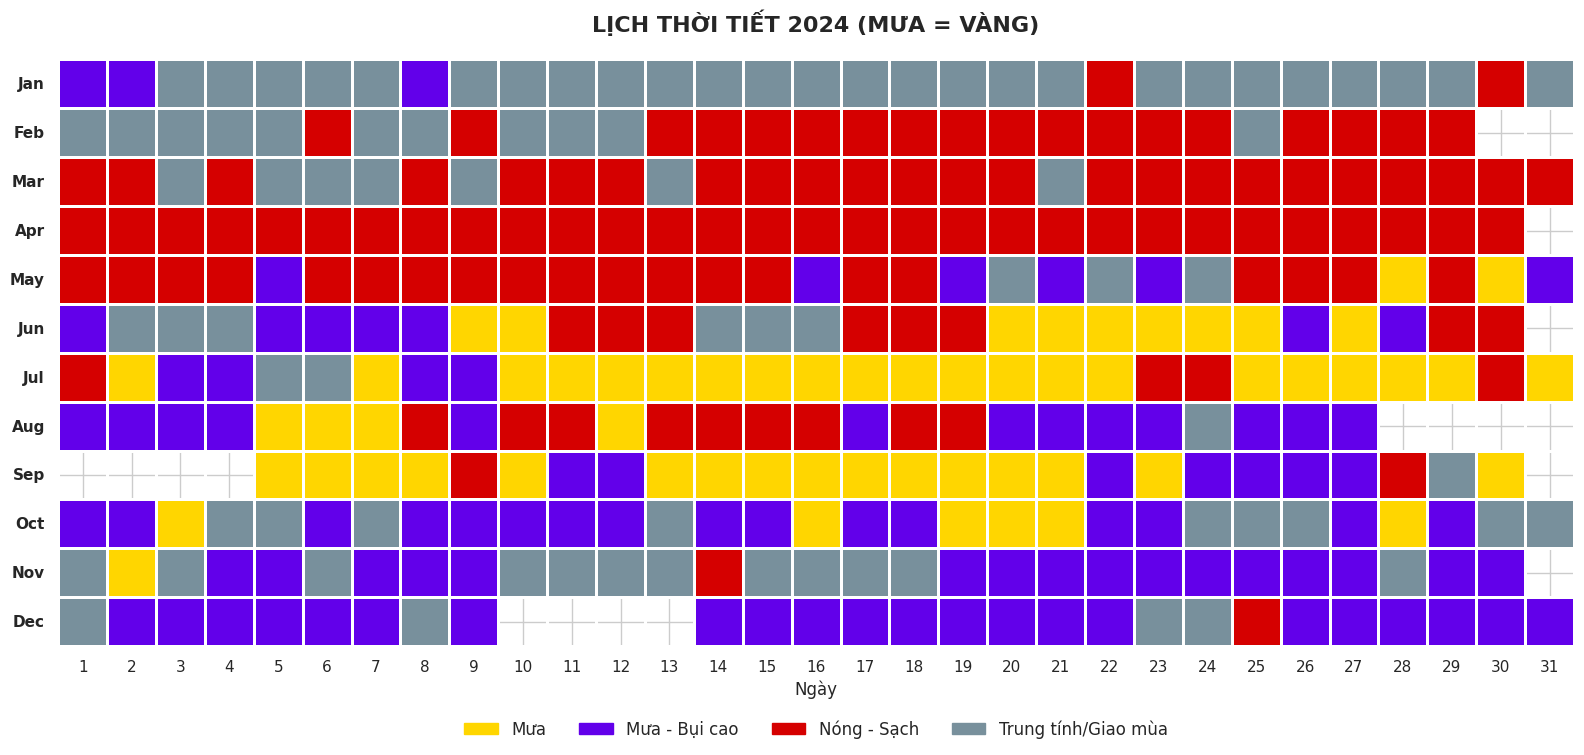

In [7]:
# 1. Data Processing
if 'date' not in df_cluster.columns:
    source_col = 'time' if 'time' in df_cluster.columns else (df_cluster.index.name or df_cluster.columns[0])
    if source_col not in df_cluster.columns: df_cluster = df_cluster.reset_index()
    df_cluster['date'] = pd.to_datetime(df_cluster[source_col])
else:
    df_cluster['date'] = pd.to_datetime(df_cluster['date'])

df_cluster['Month'] = df_cluster['date'].dt.month
df_cluster['Day'] = df_cluster['date'].dt.day

unique_names = sorted(df_cluster['Cluster_Name'].unique())
name_to_num = {name: i for i, name in enumerate(unique_names)}
df_cluster['Cluster_Num'] = df_cluster['Cluster_Name'].map(name_to_num)

calendar_df = df_cluster.pivot(index='Month', columns='Day', values='Cluster_Num')

# 2. Color Config (RAIN = YELLOW)
colors_list = []
for name in unique_names:
    n = name.lower()
    # Ưu tiên Bụi trước, sau đó đến Mưa Vàng
    if 'bụi' in n or 'ô nhiễm' in n: c = '#6200EA'   # Tím
    elif 'mưa' in n: c = '#FFD600'                   # Vàng (Rain)
    elif 'nóng' in n: c = '#D50000'                  # Đỏ
    elif 'khô' in n: c = '#FF6D00'                   # Cam
    elif 'sạch' in n or 'mát' in n: c = '#00C853'    # Xanh Lá
    else: c = '#78909C'                              # Xám
    colors_list.append(c)

cmap = mcolors.ListedColormap(colors_list)
bounds = range(len(unique_names) + 1)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# 3. Plotting
plt.figure(figsize=(16, 8))
ax = sns.heatmap(
    calendar_df, 
    cmap=cmap, norm=norm,
    linewidths=1, linecolor='white',
    square=True, cbar=False, annot=False
)

ax.set_title('LỊCH THỜI TIẾT 2024 (MƯA = VÀNG)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Ngày', fontsize=12)
ax.set_ylabel('')
ax.set_yticks([i + 0.5 for i in range(12)])
ax.set_yticklabels([calendar.month_abbr[i] for i in range(1, 13)], rotation=0, fontweight='bold')

patches = [mpatches.Patch(color=colors_list[i], label=unique_names[i]) for i in range(len(unique_names))]
plt.legend(handles=patches, bbox_to_anchor=(0.5, -0.1), loc='upper center', ncol=4, frameon=False, fontsize=12)

plt.tight_layout()
plt.savefig('../figures/11_kmeans_calendar_heatmap_yellow.pdf', bbox_inches='tight')
plt.show()

#### 5.3 Summary table

In [8]:
cols_to_analyze = ['temp_mean', 'precip_total', 'wind_speed_mean', 'uv_max', 'pm2_5_mean', 'ozone_mean']
summary = df_cluster.groupby('Cluster_Name')[cols_to_analyze].mean().round(2)

summary['Số ngày'] = df_cluster['Cluster_Name'].value_counts()
summary['Tỷ trọng (%)'] = (summary['Số ngày'] / len(df_cluster) * 100).round(1)

cols_order = ['Số ngày', 'Tỷ trọng (%)'] + cols_to_analyze
summary_final = summary[cols_order]

print("BẢNG TỔNG HỢP ĐẶC TRƯNG CÁC CỤM KHÍ HẬU (CLUSTER PROFILES):")
display(summary_final)
        
report_path = '../reports/clustering_summary.csv'
os.makedirs('../reports', exist_ok=True) # Đảm bảo thư mục tồn tại
summary_final.to_csv(report_path)
print(f"\n✅ Đã lưu báo cáo chi tiết tại: {report_path}")

BẢNG TỔNG HỢP ĐẶC TRƯNG CÁC CỤM KHÍ HẬU (CLUSTER PROFILES):


,Số ngày,Tỷ trọng (%),temp_mean,precip_total,wind_speed_mean,uv_max,pm2_5_mean,ozone_mean
Cluster_Name,,,,,,,,
Mưa,59,16.70,28.06,16.63,13.84,7.59,20.62,41.03
Mưa - Bụi cao,94,26.60,28.17,5.98,8.19,7.31,30.47,45.46
Nóng - Sạch,119,33.60,30.69,1.38,13.09,10.78,15.99,56.71
Trung tính/Giao mùa,82,23.20,28.86,1.17,8.97,8.79,25.54,72.03



✅ Đã lưu báo cáo chi tiết tại: ../reports/clustering_summary.csv


## 6.Kết luận

### Kết quả chính:

**K-Means Clustering Model:**
* Sử dụng thuật toán **K-Means** để phân nhóm các ngày trong năm 2024.
* **Đặc trưng đầu vào (Features):** Nhiệt độ, Mưa, Gió, UV, PM2.5, Ozone.
* **Số lượng cụm tối ưu (k):** 4 cụm (xác định qua Elbow Method).
* **Các nhóm nhận diện:** Mưa, Nóng khô, Ô nhiễm (Bụi), Mát mẻ/Sạch.

### Ý nghĩa của các Metrics:

* **Silhouette Score:** Hệ số dáng điệu (thang đo -1 đến 1).
    * Đo lường mức độ tách biệt giữa các cụm.
    * Giá trị > 0.4: Tách biệt khá tốt | < 0.2: Các cụm chồng lấn.
* **Inertia (WCSS):** Tổng bình phương khoảng cách đến tâm cụm.
    * Càng nhỏ càng tốt, dùng để xác định điểm gãy (Elbow) khi chọn k.

### Điểm mạnh của phương pháp:

* **Tự động hóa (Unsupervised):** Phát hiện quy luật thời tiết mà không cần dán nhãn trước.
* **Dễ giải thích:** Các cụm tìm được khớp với thực tế (Mùa mưa/khô, Ngày bụi).
* **Trực quan hóa mạnh mẽ:** Biểu đồ Calendar Heatmap giúp nhìn thấy diễn biến theo mùa rõ ràng.
* **Ứng dụng:** Nhãn cụm (Labels) là đầu vào quan trọng cho mô hình dự báo.

### Hạn chế và hướng cải thiện:

* **Giả định hình cầu:** K-Means giả định cụm hình tròn, có thể lệch nếu dữ liệu phức tạp.
    * *Cải thiện:* Thử nghiệm DBSCAN hoặc Hierarchical Clustering.
* **Nhạy cảm với Outliers:** Ngày thời tiết cực đoan có thể làm lệch tâm cụm.
    * *Cải thiện:* Loại bỏ ngoại lai (Outlier Removal) kỹ hơn.
* **Cần chọn k thủ công:** Phải quan sát biểu đồ Elbow.
    * *Cải thiện:* Dùng chỉ số Gap Statistic để gợi ý k tự động.

### Files được tạo:

* `../processed/daily_weather_aqi_clustered.csv` - Dataset đã gán nhãn
* `../reports/clustering_summary.csv`: Bảng báo cáo số liệu chi tiết từng cụm.
* `../figures/10_kmeans_pca_scatter_yellow_rain.pdf` - Biểu đồ phân bố (PCA)
* `../figures/11_kmeans_calendar_heatmap_yellow.pdf` - Biểu đồ Lịch (Heatmap)
